In [ ]:
import kagglehub
import pandas as pd
import numpy as np
!pip install category_encoders
from category_encoders.hashing import HashingEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Download latest version
path = kagglehub.dataset_download("aliafzal9323/chicago-crime-dataset-2024-2026")
#path is /kaggle/input/chicago-crime-dataset-2024-2026/chicago crimes.csv
print("Path to dataset files:", path)

#params: ID Case Number, Date, Block, IUCR, Primary Type, Description, Location Description, Arrest, Domestic, Ward, Community Area,
#FBI Code,  X Coordinate, Y Coordinate,  Year, Updated On
3


33, Latitude ,Longitude, Location

df = pd.read_csv(path + "/chicago crimes.csv")
df = df[(df['Year'] == 2024) | (df['Year'] == 2025) | (df['Year'] == 2026)] #we might want to create 2026 as a seperate CSV for use as a training set

df.to_csv("crime_2024-2026.csv")


Using Colab cache for faster access to the 'chicago-crime-dataset-2024-2026' dataset.
Path to dataset files: /kaggle/input/chicago-crime-dataset-2024-2026


(520417, 23)
(495460, 31)
(24957, 31)
(495460, 29)
(24957, 29)
Decision Tree + Linear SVC -> Logistic Regression (5-CV) REPORT
              precision    recall  f1-score   support

       False       0.95      0.77      0.85     20963
        True       0.39      0.79      0.52      3994

    accuracy                           0.77     24957
   macro avg       0.67      0.78      0.68     24957
weighted avg       0.86      0.77      0.80     24957

Accuracy: 0.7691629602917017
Random Forest + Linear SVC -> Logistic Regression (5-CV) REPORT
              precision    recall  f1-score   support

       False       0.94      0.84      0.89     20963
        True       0.47      0.74      0.57      3994

    accuracy                           0.82     24957
   macro avg       0.71      0.79      0.73     24957
weighted avg       0.87      0.82      0.84     24957

Accuracy: 0.8227351043795328
XGBoost + Linear SVC -> MLP (2-CV) REPORT
              precision    recall  f1-score   support



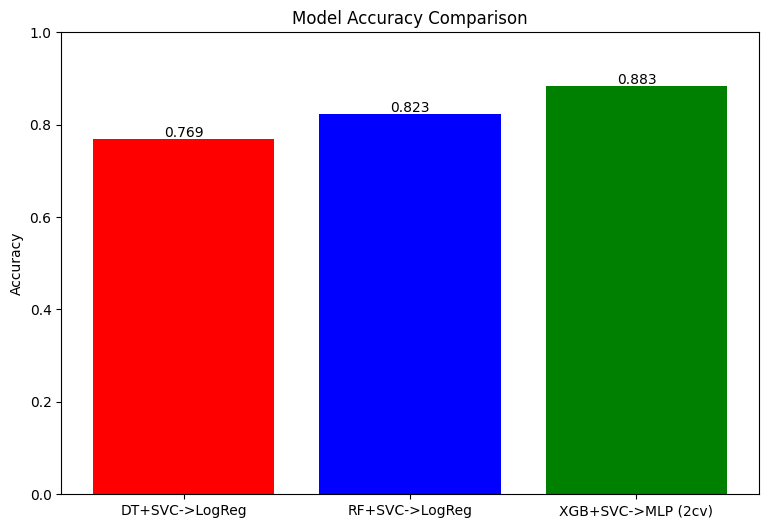

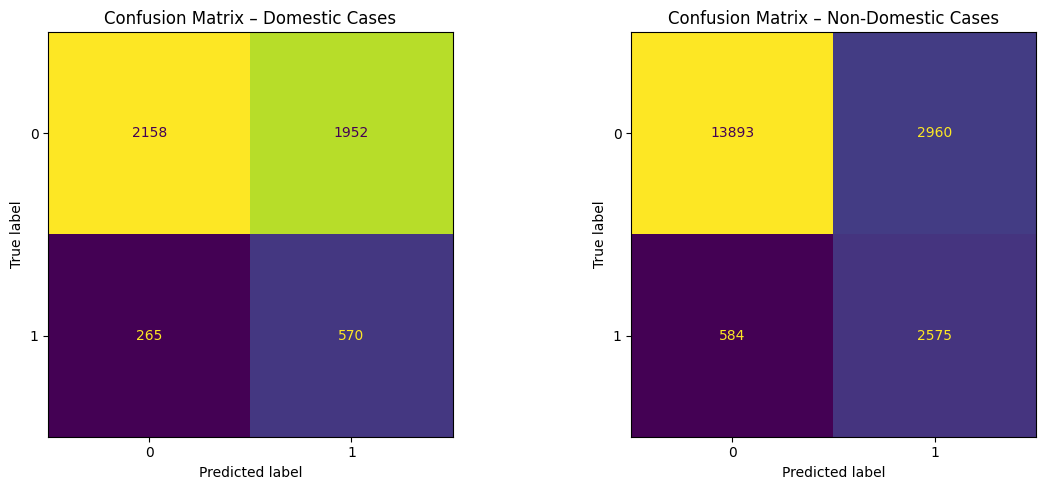

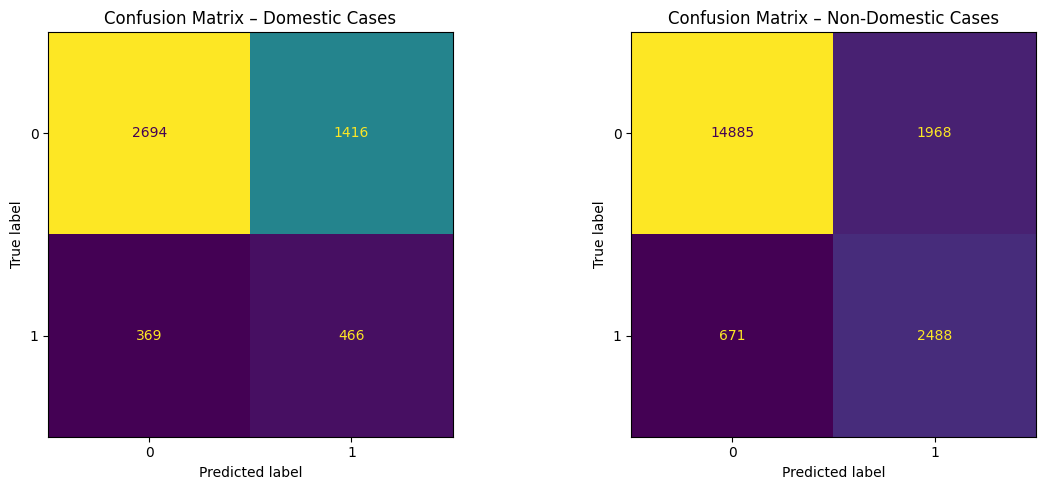

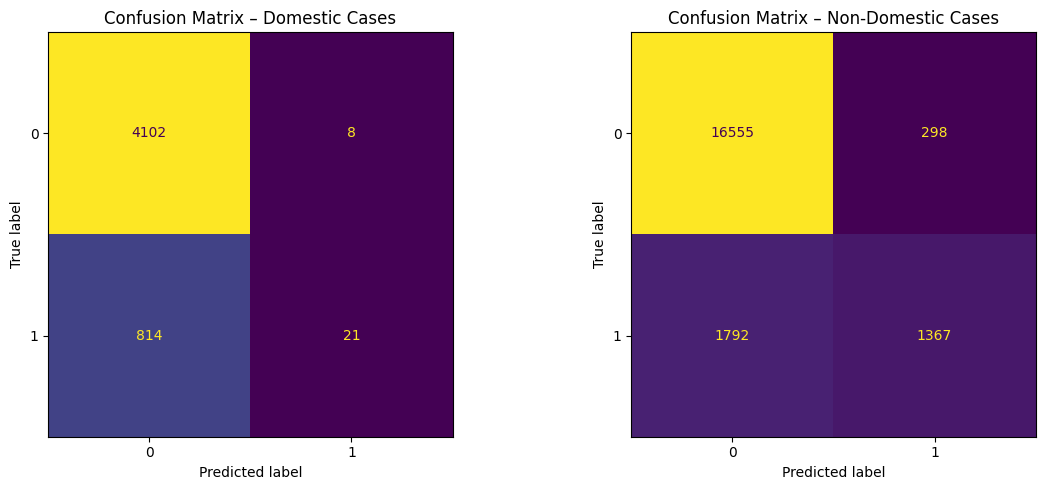

In [ ]:
df = pd.read_csv("crime_2024-2026.csv")
print(df.shape)

# -----------------------------
# CLEANING
# -----------------------------
df = df.drop([
    'ID', 'Case Number', 'Updated On', 'Latitude', 'Longitude',
    'X Coordinate', 'Y Coordinate', 'Date', 'Location'
], axis=1)

boolConv = lambda x: x.astype(str).str.strip().str.upper().map({'TRUE': True, 'FALSE': False})
strConv = lambda x: x.astype(str).str.strip()

df['Arrest'] = boolConv(df['Arrest'])
df['Domestic'] = boolConv(df['Domestic'])

# Convert categorical text
df['Primary Type'] = strConv(df['Primary Type'])
df['Location Description'] = strConv(df['Location Description'])
df['Description'] = strConv(df['Description'])
df['Block'] = strConv(df['Block'])

# Convert numeric fields
for c in ['Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'Year']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# -----------------------------
# TARGET ENCODING (ARREST RATE)
# -----------------------------
df['PrimaryType_arrest_rate'] = df['Primary Type'].map(df.groupby('Primary Type')['Arrest'].mean())
df['LocationDesc_arrest_rate'] = df['Location Description'].map(df.groupby('Location Description')['Arrest'].mean())
df['IUCR_arrest_rate'] = df['IUCR'].map(df.groupby('IUCR')['Arrest'].mean())

# -----------------------------
# FREQUENCY ENCODING
# -----------------------------
df['PrimaryType_freq'] = df['Primary Type'].map(df['Primary Type'].value_counts())
df['LocationDesc_freq'] = df['Location Description'].map(df['Location Description'].value_counts())
df['IUCR_freq'] = df['IUCR'].map(df['IUCR'].value_counts())

# -----------------------------
# HASHING ENCODING (BIG FIELDS)
# -----------------------------
hash_encoder = HashingEncoder(n_components=16)
hashed = hash_encoder.fit_transform(df[['Block', 'Description']])
df = pd.concat([df, hashed], axis=1)

# Drop raw high-cardinality columns
df = df.drop(['Primary Type', 'Location Description', 'IUCR', 'Block', 'Description'], axis=1)

# -----------------------------
# TRAIN/TEST SPLIT
# -----------------------------
train = df[(df['Year'] == 2024) | (df['Year'] == 2025)]
test = df[df['Year'] == 2026]

print(train.shape)
print(test.shape)
X_train = train.drop(['Domestic', 'Arrest'], axis=1)
X_test  = test.drop(['Domestic', 'Arrest'], axis=1)

print(X_train.shape)
print(X_test.shape)
y_train = train['Arrest']
y_test  = test['Arrest']

# -----------------------------
# MODEL 1: Decision Tree + Linear SVC -> Logistic Regression (5-CV)
# -----------------------------

estimators1 = [
    ('dt', DecisionTreeClassifier(class_weight='balanced')),
    ('lin_svc', LinearSVC(class_weight='balanced'))
]

stack1 = StackingClassifier(
    estimators=estimators1,
    final_estimator=LogisticRegression(max_iter=300, class_weight='balanced'),
    cv=5
)

model1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('stack', stack1)
])

model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
m1 = accuracy_score(y_test, y_pred1)
print("Decision Tree + Linear SVC -> Logistic Regression (5-CV) REPORT")
print(classification_report(y_test, y_pred1))
print("Accuracy:", m1)


# -----------------------------
# MODEL 2: Random Forest + Linear SVC -> Logistic Regression (5-CV)
# -----------------------------

estimators2 = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        n_jobs=-1
    )),
    ('lin_svc', LinearSVC(class_weight='balanced'))
]

stack2 = StackingClassifier(
    estimators=estimators2,
    final_estimator=LogisticRegression(max_iter=300, class_weight='balanced'),
    cv=5
)

model2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('stack', stack2)
])

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
m2 = accuracy_score(y_test, y_pred2)
print("Random Forest + Linear SVC -> Logistic Regression (5-CV) REPORT")
print(classification_report(y_test, y_pred2))
print("Accuracy:", m2)


# -----------------------------
# MODEL 3: XGBoost + Linear SVC -> MLP (2-CV)
# -----------------------------

estimators3 = [
    ('xgb', XGBClassifier(
        n_estimators=3,
        max_depth=2,
        learning_rate=1,
        objective='binary:logistic'
    )),
    ('lin_svc', LinearSVC(class_weight='balanced'))
]

stack3 = StackingClassifier(
    estimators=estimators3,
    final_estimator=MLPClassifier(activation='relu', solver='adam', hidden_layer_sizes=(100, 100, 100)),
    cv=2
)

model3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('stack', stack3)
])

model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
m3 = accuracy_score(y_test, y_pred3)
print("XGBoost + Linear SVC -> MLP (2-CV) REPORT")
print(classification_report(y_test, y_pred3))
print("Accuracy:", m3)
'''
# -----------------------------
# STACKING MODEL (XGBoost + Linear SVC with MLP Classifier)
# -----------------------------

estimators = [
    ('xgb', XGBClassifier(n_estimators=3, max_depth=2, learning_rate=1, objective='binary:logistic')),
    ('lin_svc', LinearSVC(class_weight='balanced'))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=MLPClassifier(activation='relu', solver='adam', hidden_layer_sizes=(100, 100, 100)),
    cv=5
)

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('stack', stack)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
m2 = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(m2)

# -----------------------------
# STACKING MODEL (Decision Tree + Linear SVC with Logistic Regression) 2-CV
# -----------------------------

estimators = [
    ('dt', DecisionTreeClassifier(class_weight='balanced')),
    ('lin_svc', LinearSVC(class_weight='balanced'))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=300, class_weight='balanced'),
    cv=2
)

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('stack', stack)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
m3 = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(m3)
'''

# -----------------------------
# Accuracy and Confusion Matrix
# -----------------------------
scores = [m1, m2, m3]
labels = ['DT+SVC->LogReg', 'RF+SVC->LogReg', 'XGB+SVC->MLP (2cv)']

plt.figure(figsize=(9,6))
bars = plt.bar(labels, scores, color=['r', 'b', 'g'])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}", ha='center')

plt.ylim(0, 1)
plt.show()

# Confusion Matrices
pred_set = [y_pred1, y_pred2, y_pred3]
for i in pred_set:
  chosen_pred = i

  mask_domestic = test['Domestic'] == True
  mask_not_domestic = test['Domestic'] == False

  cm_domestic = confusion_matrix(y_test[mask_domestic], chosen_pred[mask_domestic])
  cm_not_domestic = confusion_matrix(y_test[mask_not_domestic], chosen_pred[mask_not_domestic])

  fig, ax = plt.subplots(1, 2, figsize=(12,5))

  ConfusionMatrixDisplay(cm_domestic).plot(ax=ax[0], colorbar=False)
  ax[0].set_title("Confusion Matrix – Domestic Cases")

  ConfusionMatrixDisplay(cm_not_domestic).plot(ax=ax[1], colorbar=False)
  ax[1].set_title("Confusion Matrix – Non‑Domestic Cases")

  plt.tight_layout()
  plt.show()